# Modélisation avancée — Credit Scoring

Ce notebook compare plusieurs modèles à la baseline de la phase 2, tune le meilleur d'entre eux,
puis choisit un **seuil de décision** adapté au coût métier des erreurs.

**Règles** :
- On travaille uniquement sur le train déjà préparé (`X_train_processed.csv`, `y_train.csv`).
  Le test n'est jamais chargé ici : il servira une seule fois, à l'évaluation finale.
- Tous les modèles sont évalués avec **la même validation croisée stratifiée à 5 folds**
  (même `random_state`, donc exactement les mêmes découpages) que la baseline.
- Métrique principale : **AUC-PR** (cf. README). On suit aussi AUC-ROC, recall et precision
  sur la classe défaut.

In [1]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from scipy.stats import randint, uniform, loguniform

from sklearn.base import clone
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.model_selection import (
    StratifiedKFold,
    cross_validate,
    cross_val_predict,
    RandomizedSearchCV,
)
from sklearn.metrics import (
    make_scorer,
    precision_score,
    recall_score,
    average_precision_score,
    roc_auc_score,
    precision_recall_curve,
)

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)

# Palette catégorielle (3 premiers slots, validée pour la lisibilité daltonien/normal)
BLUE, ORANGE, AQUA = "#2a78d6", "#eb6834", "#1baf7a"

RANDOM_STATE = 42

## 0. Chargement du train préparé

`X_train_processed.csv` contient les features déjà nettoyées, enrichies et standardisées en
phase 2 (scaler fit sur le train uniquement). Les modèles à base d'arbres n'ont pas besoin de
standardisation, mais celle-ci est sans effet sur eux (transformation monotone par variable) :
on garde donc **le même jeu de données pour tous les modèles**, ce qui garantit une comparaison
équitable.

In [2]:
X_train = pd.read_csv("../data/processed/X_train_processed.csv", index_col="id")
y_train = pd.read_csv("../data/processed/y_train.csv", index_col="id")["SeriousDlqin2yrs"]

# Les indicatrices one-hot sont lues comme booléennes : on convertit tout en float
X_train = X_train.astype(float)

assert X_train.index.equals(y_train.index), "X et y ne sont pas alignés"
print("X_train :", X_train.shape, "| proportion de défauts :", y_train.mean().round(4))

X_train : (120000, 23) | proportion de défauts : 0.0668


## 1. Comparaison des modèles (seuil 0.5 par défaut)

Modèles comparés, tous configurés pour gérer le déséquilibre de classes (~6,7 % de défauts) :

- **Régression logistique** (phase 2) : référence, recalculée ici pour que le tableau soit
  produit dans les mêmes conditions que les autres modèles.
- **Random Forest** avec `class_weight="balanced"`. On limite la taille des arbres
  (`min_samples_leaf=10`) : des arbres entièrement développés donnent des probabilités très
  "en escalier" (souvent 0 ou 1), ce qui dégrade le classement des clients et donc l'AUC-PR.
- **XGBoost** avec `scale_pos_weight = n_négatifs / n_positifs` (~14) : chaque défaut pèse
  autant que ~14 non-défauts dans la fonction de perte.
- **LightGBM** avec `class_weight="balanced"` (même principe de pondération).

Les deux modèles de boosting reçoivent la même configuration de départ (300 arbres, profondeur 4,
learning rate 0.05) pour une comparaison équitable avant tuning. Le `DummyClassifier` reste en
référence plancher.

In [3]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

# zero_division=0 : évite les warnings quand un modèle ne prédit jamais la classe défaut (Dummy)
scoring = {
    "average_precision": "average_precision",
    "roc_auc": "roc_auc",
    "recall": make_scorer(recall_score, zero_division=0),
    "precision": make_scorer(precision_score, zero_division=0),
}

# Poids de la classe minoritaire pour XGBoost, calculé sur le déséquilibre du train
n_neg, n_pos = (y_train == 0).sum(), (y_train == 1).sum()
scale_pos_weight = n_neg / n_pos
print(f"scale_pos_weight = {n_neg} / {n_pos} = {scale_pos_weight:.2f}")

models = {
    "Dummy (classe majoritaire)": DummyClassifier(strategy="most_frequent"),
    "Régression logistique": LogisticRegression(
        class_weight="balanced", max_iter=1000, random_state=RANDOM_STATE
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators=200, min_samples_leaf=10, class_weight="balanced",
        n_jobs=-1, random_state=RANDOM_STATE,
    ),
    "XGBoost": XGBClassifier(
        n_estimators=300, max_depth=4, learning_rate=0.05,
        scale_pos_weight=scale_pos_weight, eval_metric="aucpr",
        random_state=RANDOM_STATE,
    ),
    "LightGBM": LGBMClassifier(
        n_estimators=300, max_depth=4, learning_rate=0.05,
        class_weight="balanced", random_state=RANDOM_STATE, verbose=-1,
    ),
}

scale_pos_weight = 111979 / 8021 = 13.96


In [4]:
# results[nom_modele][metrique] = (moyenne sur les 5 folds, écart-type)
results = {}
for name, model in models.items():
    cv_res = cross_validate(model, X_train, y_train, cv=cv, scoring=scoring)
    results[name] = {m: (cv_res[f"test_{m}"].mean(), cv_res[f"test_{m}"].std()) for m in scoring}
    results[name]["fit_time"] = (cv_res["fit_time"].mean(), cv_res["fit_time"].std())
    print(f"{name}: AUC-PR = {results[name]['average_precision'][0]:.3f}")

Dummy (classe majoritaire): AUC-PR = 0.067


Régression logistique: AUC-PR = 0.383


Random Forest: AUC-PR = 0.392


XGBoost: AUC-PR = 0.401


LightGBM: AUC-PR = 0.402


In [5]:
COLUMN_LABELS = {
    "average_precision": "AUC-PR",
    "roc_auc": "AUC-ROC",
    "recall": "Recall (défaut)",
    "precision": "Precision (défaut)",
    "fit_time": "Temps fit (s)",
}

def results_table(results_dict):
    """Tableau lisible 'moyenne (+/- écart-type)' à partir d'un dict de résultats."""
    table = pd.DataFrame(
        {
            name: {COLUMN_LABELS[m]: f"{mean:.3f} (+/- {std:.3f})" for m, (mean, std) in metrics.items()
                   if m in COLUMN_LABELS}
            for name, metrics in results_dict.items()
        }
    ).T
    return table.fillna("-")   # pas de temps de fit pour les lignes calculées hors CV

results_table(results)

,AUC-PR,AUC-ROC,Recall (défaut),Precision (défaut),Temps fit (s)
Dummy (classe majoritaire),0.067 (+/- 0.000),0.500 (+/- 0.000),0.000 (+/- 0.000),0.000 (+/- 0.000),0.032 (+/- 0.003)
Régression logistique,0.383 (+/- 0.007),0.857 (+/- 0.004),0.741 (+/- 0.010),0.217 (+/- 0.001),0.364 (+/- 0.033)
Random Forest,0.392 (+/- 0.003),0.860 (+/- 0.003),0.695 (+/- 0.008),0.260 (+/- 0.004),4.341 (+/- 0.197)
XGBoost,0.401 (+/- 0.005),0.864 (+/- 0.003),0.771 (+/- 0.006),0.216 (+/- 0.001),1.297 (+/- 0.070)
LightGBM,0.402 (+/- 0.005),0.865 (+/- 0.003),0.773 (+/- 0.005),0.216 (+/- 0.001),0.901 (+/- 0.013)


## 2. Tuning du meilleur modèle

On retient le modèle à base d'arbres avec le meilleur **AUC-PR en CV** (la régression logistique
reste la référence à battre). Le tuning se fait avec `RandomizedSearchCV` : plutôt que d'essayer
toutes les combinaisons (grille), on tire 25 configurations au hasard dans un espace raisonnable.
C'est nettement moins coûteux et, à budget égal, généralement aussi efficace qu'une grille
(Bergstra & Bengio, 2012). L'optimisation porte directement sur l'**AUC-PR** avec la même CV.

*Note d'honnêteté* : le score du meilleur jeu d'hyperparamètres est légèrement **optimiste**
(il a été sélectionné parce qu'il était le meilleur sur ces mêmes folds). Le vrai verdict
viendra de l'évaluation finale sur le test.

In [6]:
tree_models = ["Random Forest", "XGBoost", "LightGBM"]
best_name = max(tree_models, key=lambda n: results[n]["average_precision"][0])
print("Meilleur modèle en CV (AUC-PR) :", best_name)
print(f"  AUC-PR = {results[best_name]['average_precision'][0]:.3f} "
      f"(régression logistique : {results['Régression logistique']['average_precision'][0]:.3f})")

Meilleur modèle en CV (AUC-PR) : LightGBM
  AUC-PR = 0.402 (régression logistique : 0.383)


In [7]:
# Espaces de recherche par modèle (n_estimators, profondeur, learning rate, taille minimale des feuilles)
param_distributions = {
    "Random Forest": {
        "n_estimators": randint(200, 501),
        "max_depth": randint(5, 16),
        "min_samples_leaf": randint(5, 51),
        "max_features": ["sqrt", 0.5],
    },
    "XGBoost": {
        "n_estimators": randint(200, 801),
        "max_depth": randint(3, 8),
        "learning_rate": loguniform(0.01, 0.2),
        "min_child_weight": randint(1, 21),
        "subsample": uniform(0.6, 0.4),          # entre 0.6 et 1.0
        "colsample_bytree": uniform(0.6, 0.4),   # entre 0.6 et 1.0
    },
    "LightGBM": {
        "n_estimators": randint(200, 801),
        "max_depth": randint(3, 9),
        "num_leaves": randint(8, 64),
        "learning_rate": loguniform(0.01, 0.2),
        "min_child_samples": randint(20, 201),   # équivalent LightGBM de min_child_weight (nb d'observations)
        "colsample_bytree": uniform(0.6, 0.4),
    },
}

search = RandomizedSearchCV(
    estimator=clone(models[best_name]),
    param_distributions=param_distributions[best_name],
    n_iter=25,
    scoring="average_precision",
    cv=cv,
    random_state=RANDOM_STATE,
    n_jobs=1,          # les modèles utilisent déjà tous les coeurs en interne
    refit=True,        # ré-entraîne le meilleur modèle sur tout le train
    verbose=1,
)
search.fit(X_train, y_train)

Fitting 5 folds for each of 25 candidates, totalling 125 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","LGBMClassifie...2, verbose=-1)"
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'colsample_bytree': <scipy.stats....001F7F620E3F0>, 'learning_rate': <scipy.stats....001F7F620F360>, 'max_depth': <scipy.stats....001F7F633C050>, 'min_child_samples': <scipy.stats....001F7F626FC50>, ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",25
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'average_precision'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"verbose verbose: int, default = 0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",1
,"random_state random_state: int, RandomState instance or None, default=NonePseudo random number generator state used for random uniform samplingfrom lists of possible values instead of scipy.stats distributions.Pass an int for reproducible output across multiplefunction calls.See :term:`Glossary <random_state>`.",42
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are

In [8]:
print("Meilleurs hyperparamètres :")
for k, v in search.best_params_.items():
    print(f"  {k}: {v}")
print(f"\nAUC-PR CV (tuné)   : {search.best_score_:.3f}")
print(f"AUC-PR CV (avant)  : {results[best_name]['average_precision'][0]:.3f}")

# Top 5 des configurations : montre si le gain vient d'un vrai optimum ou d'un plateau
top5 = (
    pd.DataFrame(search.cv_results_)
    .sort_values("rank_test_score")
    .head(5)[["mean_test_score", "std_test_score"]]
    .round(4)
)
top5

Meilleurs hyperparamètres :
  colsample_bytree: 0.798070764044508
  learning_rate: 0.011085122517311707
  max_depth: 8
  min_child_samples: 100
  n_estimators: 761
  num_leaves: 47

AUC-PR CV (tuné)   : 0.403
AUC-PR CV (avant)  : 0.402


,mean_test_score,std_test_score
9,0.4034,0.0041
6,0.4034,0.0035
15,0.4034,0.0036
1,0.4034,0.0040
20,0.4033,0.0035


## 3. Choix du seuil de décision

Le modèle produit une **probabilité de défaut**. Transformer cette probabilité en décision
(accorder / refuser) exige un seuil : au-dessus, on refuse. Le seuil par défaut de 0.5 n'a aucune
raison d'être optimal ici, d'autant que les classes sont pondérées (les probabilités sont
décalées vers le haut par `scale_pos_weight` / `class_weight`).

Pour choisir le seuil **sans toucher au test**, on utilise des prédictions *out-of-fold* : chaque
client est noté par un modèle qui ne l'a jamais vu à l'entraînement (`cross_val_predict`, même CV).

In [9]:
# Modèle tuné (non entraîné) avec les meilleurs hyperparamètres, pour produire des probabilités out-of-fold
y_proba_oof = cross_val_predict(
    clone(search.best_estimator_), X_train, y_train, cv=cv, method="predict_proba"
)[:, 1]

def fold_metrics(y_true, y_proba, threshold):
    """Métriques par fold (mêmes découpages que la CV) à un seuil donné : (moyenne, écart-type)."""
    rows = []
    for _, idx in cv.split(X_train, y_train):
        yt, yp = y_true.iloc[idx], y_proba[idx]
        pred = (yp >= threshold).astype(int)
        rows.append({
            "average_precision": average_precision_score(yt, yp),
            "roc_auc": roc_auc_score(yt, yp),
            "recall": recall_score(yt, pred, zero_division=0),
            "precision": precision_score(yt, pred, zero_division=0),
        })
    df = pd.DataFrame(rows)
    return {m: (df[m].mean(), df[m].std(ddof=0)) for m in df.columns}

print(f"AUC-PR out-of-fold (poolé) : {average_precision_score(y_train, y_proba_oof):.3f}")

AUC-PR out-of-fold (poolé) : 0.403


In [10]:
# Table recall / precision / coûts pour une grille de seuils (sur les prédictions out-of-fold)
is_default = (y_train == 1).values
rows = []
for t in np.round(np.arange(0.05, 0.96, 0.01), 2):
    pred = y_proba_oof >= t
    tp = (pred & is_default).sum()
    fp = (pred & ~is_default).sum()
    fn = (~pred & is_default).sum()
    rows.append({
        "threshold": t,
        "recall": tp / (tp + fn),
        "precision": tp / (tp + fp) if (tp + fp) > 0 else np.nan,
        "n_refused": tp + fp,                   # clients refusés (crédit non accordé)
        "false_negatives": fn,                  # mauvais payeurs acceptés
        "false_positives": fp,                  # bons clients refusés
    })
threshold_table = pd.DataFrame(rows).set_index("threshold")
threshold_table["f1"] = (
    2 * threshold_table["precision"] * threshold_table["recall"]
    / (threshold_table["precision"] + threshold_table["recall"])
)
threshold_table.loc[[0.10, 0.20, 0.30, 0.40, 0.50, 0.60, 0.70, 0.80]].round(3)

,recall,precision,n_refused,false_negatives,false_positives,f1
threshold,,,,,,
0.1,0.975,0.090,87187,200,79366,0.164
0.2,0.924,0.123,60181,608,52768,0.217
0.3,0.880,0.153,45988,965,38932,0.261
0.4,0.823,0.185,35674,1419,29072,0.302
0.5,0.759,0.226,26926,1935,20840,0.348
0.6,0.676,0.278,19507,2597,14083,0.394
0.7,0.586,0.342,13720,3322,9021,0.432
0.8,0.476,0.420,9087,4202,5268,0.446


### Trois seuils candidats

Trois façons de choisir le seuil, correspondant à trois priorités métier :

- **Prudent** : le seuil le plus haut qui garantit un recall d'au moins 80 % — on veut détecter
  la grande majorité des mauvais payeurs, quitte à refuser beaucoup de bons clients.
- **Équilibré** : le seuil qui maximise le F1 (compromis mathématique entre recall et precision,
  sans hypothèse de coût).
- **Permissif** : le seuil le plus bas qui garantit une precision d'au moins 35 % — on refuse
  moins de bons clients, quitte à laisser passer plus de mauvais payeurs.

In [11]:
candidates = {
    "Prudent (recall >= 80 %)": threshold_table[threshold_table["recall"] >= 0.80].index.max(),
    "Équilibré (F1 max)": threshold_table["f1"].idxmax(),
    "Permissif (precision >= 35 %)": threshold_table[threshold_table["precision"] >= 0.35].index.min(),
}

cand_table = threshold_table.loc[list(candidates.values()), ["recall", "precision", "n_refused",
                                                             "false_negatives", "false_positives"]]
cand_table.insert(0, "profil", list(candidates.keys()))
cand_table.round(3)

,profil,recall,precision,n_refused,false_negatives,false_positives
threshold,,,,,,
0.43,Prudent (recall >= 80 %),0.805,0.196,32897,1562,26438
0.80,Équilibré (F1 max),0.476,0.420,9087,4202,5268
0.72,Permissif (precision >= 35 %),0.564,0.356,12715,3494,8188


### Le compromis business

Refuser un client dont la probabilité de défaut dépasse le seuil : **plus le seuil est bas, plus on
refuse de clients**.

- **Seuil bas (profil prudent)** : presque tous les mauvais payeurs sont détectés (recall élevé),
  donc peu de pertes sur crédits impayés. En contrepartie, la precision est faible : la plupart
  des clients refusés étaient en réalité de bons payeurs, ce qui représente un manque à gagner
  commercial (intérêts non perçus) et une mauvaise expérience client.
- **Seuil haut (profil permissif)** : on ne refuse que les cas très risqués (precision élevée),
  donc peu de bons clients pénalisés, mais on laisse passer une part importante de mauvais
  payeurs (recall plus faible) : c'est le scénario coûteux pour la banque.
- **Seuil équilibré (F1)** : compromis mathématique, mais il suppose implicitement que les deux
  types d'erreur coûtent pareil — ce qui, d'après le README, n'est pas le cas.

Pour trancher sans arbitraire, on chiffre le **coût total** en unités où un bon client refusé
(faux positif) coûte 1 et un mauvais payeur accepté (faux négatif) coûte `k`. Le vrai `k` dépend
de la banque (montant moyen prêté, marge sur les intérêts, taux de récupération) : on teste donc
plusieurs hypothèses pour voir si le seuil optimal est robuste.

In [12]:
# Coût total = k * (mauvais payeurs acceptés) + 1 * (bons clients refusés), pour plusieurs valeurs de k
# k est une HYPOTHÈSE métier (pas une donnée) : on regarde la sensibilité du seuil optimal à k
n_clients = len(y_train)
cost_rows = []
for k in [3, 5, 10]:
    cost = k * threshold_table["false_negatives"] + threshold_table["false_positives"]
    t_opt = cost.idxmin()
    cost_rows.append({
        "k (coût FN / coût FP)": k,
        "seuil optimal": t_opt,
        "recall": threshold_table.loc[t_opt, "recall"],
        "precision": threshold_table.loc[t_opt, "precision"],
        "% clients refusés": 100 * threshold_table.loc[t_opt, "n_refused"] / n_clients,
        "surcoût du seuil 0.5 (%)": 100 * (cost.loc[0.5] / cost.loc[t_opt] - 1),
    })
pd.DataFrame(cost_rows).round(3)

,k (coût FN / coût FP),seuil optimal,recall,precision,% clients refusés,surcoût du seuil 0.5 (%)
0,3,0.80,0.476,0.420,7.572,49.071
1,5,0.74,0.547,0.373,9.810,19.409
2,10,0.57,0.702,0.261,18.006,0.871


### Choix du seuil final : 0.57

**Ce que montre le tableau des coûts** : le seuil optimal dépend fortement de `k` (0.80 pour
`k=3`, 0.74 pour `k=5`, 0.57 pour `k=10`). Le choix du seuil est donc une **décision métier**, pas
un résultat statistique : le modèle fournit un classement des clients, c'est la banque qui décide
combien de risque elle accepte.

**Décision : seuil 0.57, correspondant à `k = 10`**, pour ces raisons :

1. **Cohérence avec le cadrage du projet** : le README pose qu'accorder un crédit à un mauvais
   payeur coûte nettement plus cher que refuser un bon client. On retient `k = 10` comme ordre de
   grandeur *illustratif* (un prêt en défaut fait perdre environ 10 fois ce que rapporte un bon
   client). **C'est une hypothèse, pas une donnée** : avec les vrais montants
   (perte en cas de défaut, marge d'intérêt), la banque devrait recalculer `k`, et le seuil
   suivrait (vers 0.74-0.80 si `k` était plus faible).
2. **Rester cohérent avec l'objectif de recall** : à 0.57, on détecte environ 70 % des mauvais
   payeurs (recall 0.70) avec une precision de 0.26, en refusant 18 % des clients. Les seuils
   "permissif" (0.72) et "équilibré" (0.80) laisseraient passer 44 à 52 % des mauvais payeurs
   (recall 0.56 et 0.48), ce qui va à l'encontre de l'objectif du projet.
3. **Ne pas sur-refuser** : le seuil "prudent" (0.43) gagne environ 10 points de recall (0.80
   contre 0.70) mais refuse 27 % des clients, soit environ 10 500 bons clients refusés en plus
   sur le train (26 438 contre 15 973 faux positifs). Pour une banque qui doit aussi
   faire du chiffre d'affaires, le gain marginal ne paie pas ce coût.
4. **Robustesse** : pour `k = 10`, la courbe de coût est très plate autour de l'optimum
   (moins de 1 % d'écart avec l'optimum sur toute la plage 0.50-0.60). Choisir 0.57 plutôt que
   0.55 ne change presque rien : le chiffre exact ne doit pas être sur-interprété.

**Pourquoi 0.5 est déjà proche de l'optimum ici** : `class_weight="balanced"` revient à
supposer implicitement un rapport de coût égal au rapport des classes (~14). C'est cohérent
avec `k = 10` (surcoût du seuil 0.5 : moins de 1 %) mais **pas** avec `k = 3` ou `k = 5`, où
garder 0.5 coûterait respectivement ~49 % et ~19 % de plus que l'optimum (colonne de droite du
tableau ci-dessus).

*Limite* : ce seuil est choisi sur les prédictions out-of-fold du train ; son efficacité réelle
sera vérifiée une seule fois sur le test lors de l'évaluation finale.


In [13]:
FINAL_THRESHOLD = 0.57

final_metrics = fold_metrics(y_train, y_proba_oof, FINAL_THRESHOLD)
print(f"Seuil final : {FINAL_THRESHOLD}")
for m, (mean, std) in final_metrics.items():
    print(f"  {COLUMN_LABELS[m]}: {mean:.3f} (+/- {std:.3f})")

Seuil final : 0.57
  AUC-PR: 0.403 (+/- 0.004)
  AUC-ROC: 0.864 (+/- 0.003)
  Recall (défaut): 0.702 (+/- 0.008)
  Precision (défaut): 0.261 (+/- 0.003)


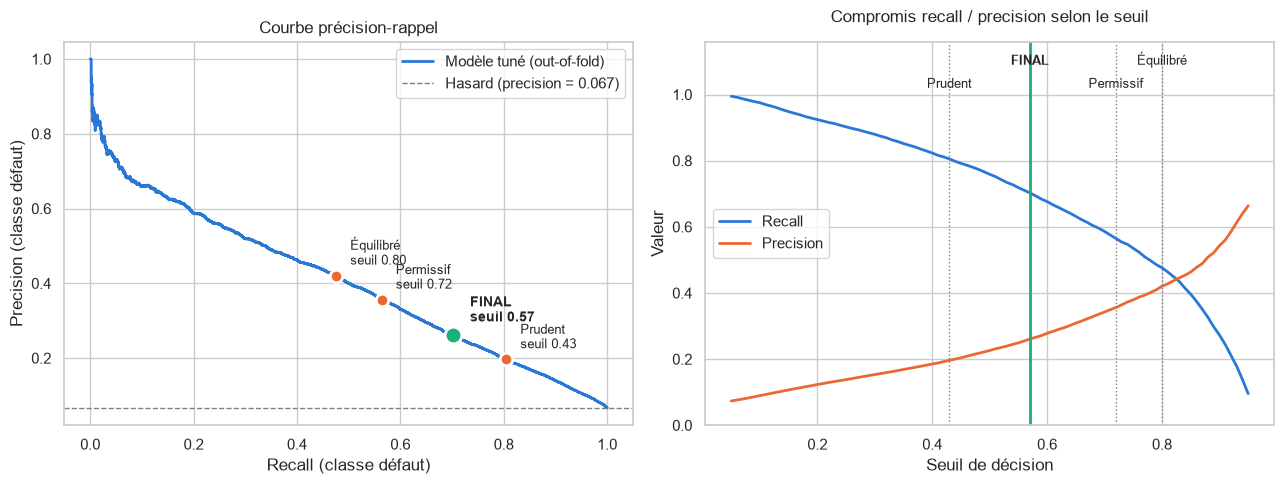

In [14]:
# Courbe précision-rappel (gauche) et recall/precision en fonction du seuil (droite)
precision, recall, _ = precision_recall_curve(y_train, y_proba_oof)
prevalence = y_train.mean()

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# --- Courbe PR ---
ax = axes[0]
ax.plot(recall, precision, color=BLUE, lw=2, label="Modèle tuné (out-of-fold)")
ax.axhline(prevalence, color="gray", ls="--", lw=1, label=f"Hasard (precision = {prevalence:.3f})")
for label, t in candidates.items():
    r, p = threshold_table.loc[t, ["recall", "precision"]]
    ax.plot(r, p, "o", color=ORANGE, ms=9, mec="white", mew=2)
    ax.annotate(f"{label.split(' ')[0]}\nseuil {t:.2f}", (r, p), textcoords="offset points",
                xytext=(10, 8), fontsize=9)
r, p = threshold_table.loc[FINAL_THRESHOLD, ["recall", "precision"]]
ax.plot(r, p, "o", color=AQUA, ms=12, mec="white", mew=2)
ax.annotate(f"FINAL\nseuil {FINAL_THRESHOLD:.2f}", (r, p), textcoords="offset points",
            xytext=(12, 10), fontsize=10, fontweight="bold")
ax.set_xlabel("Recall (classe défaut)")
ax.set_ylabel("Precision (classe défaut)")
ax.set_title("Courbe précision-rappel")
ax.legend(loc="upper right")

# --- Recall / precision vs seuil ---
ax = axes[1]
ax.plot(threshold_table.index, threshold_table["recall"], color=BLUE, lw=2, label="Recall")
ax.plot(threshold_table.index, threshold_table["precision"], color=ORANGE, lw=2, label="Precision")
# Étiquettes décalées en hauteur (une sur deux) pour éviter les chevauchements
marks = {label.split(" ")[0]: t for label, t in candidates.items()}
marks["FINAL"] = FINAL_THRESHOLD
for i, (name, t) in enumerate(sorted(marks.items(), key=lambda kv: kv[1])):
    is_final = name == "FINAL"
    ax.axvline(t, color=AQUA if is_final else "gray", ls="-" if is_final else ":", lw=2 if is_final else 1)
    ax.text(t, 1.02 + 0.07 * (i % 2), name, ha="center", fontsize=9,
            fontweight="bold" if is_final else "normal")
ax.set_xlabel("Seuil de décision")
ax.set_ylabel("Valeur")
ax.set_ylim(0, 1.16)
ax.set_title("Compromis recall / precision selon le seuil", pad=14)
ax.legend(loc="center left")

plt.tight_layout()
plt.show()

In [15]:
# Sauvegarde du modèle final (déjà ré-entraîné sur tout le train par RandomizedSearchCV) et de sa config
final_model = search.best_estimator_
joblib.dump(final_model, "../models/final_model.joblib")

def to_native(v):
    """Convertit les types numpy en types Python pour la sérialisation JSON."""
    return v.item() if hasattr(v, "item") else v

config = {
    "model": best_name,
    "threshold": FINAL_THRESHOLD,
    "best_params": {k: to_native(v) for k, v in search.best_params_.items()},
    "cv_metrics_at_threshold": {m: round(mean, 4) for m, (mean, _) in final_metrics.items()},
    "features": list(X_train.columns),
    "random_state": RANDOM_STATE,
}
with open("../models/threshold_config.json", "w", encoding="utf-8") as f:
    json.dump(config, f, indent=2, ensure_ascii=False)

print("Modèle et config sauvegardés dans models/")

Modèle et config sauvegardés dans models/


## 4. Comparaison finale

Tous les modèles testés, baseline incluse. Les modèles de la section 1 sont évalués au seuil par
défaut 0.5 ; le modèle tuné est présenté au seuil 0.5 **et** au seuil final choisi (l'AUC-PR et
l'AUC-ROC ne dépendent pas du seuil, seuls recall et precision changent).

In [16]:
summary = dict(results)
tuned_label = f"{best_name} tuné"
summary[f"{tuned_label} (seuil 0.50)"] = fold_metrics(y_train, y_proba_oof, 0.5)
summary[f"{tuned_label} (seuil {FINAL_THRESHOLD:.2f})"] = final_metrics

results_table(summary)

,AUC-PR,AUC-ROC,Recall (défaut),Precision (défaut),Temps fit (s)
Dummy (classe majoritaire),0.067 (+/- 0.000),0.500 (+/- 0.000),0.000 (+/- 0.000),0.000 (+/- 0.000),0.032 (+/- 0.003)
Régression logistique,0.383 (+/- 0.007),0.857 (+/- 0.004),0.741 (+/- 0.010),0.217 (+/- 0.001),0.364 (+/- 0.033)
Random Forest,0.392 (+/- 0.003),0.860 (+/- 0.003),0.695 (+/- 0.008),0.260 (+/- 0.004),4.341 (+/- 0.197)
XGBoost,0.401 (+/- 0.005),0.864 (+/- 0.003),0.771 (+/- 0.006),0.216 (+/- 0.001),1.297 (+/- 0.070)
LightGBM,0.402 (+/- 0.005),0.865 (+/- 0.003),0.773 (+/- 0.005),0.216 (+/- 0.001),0.901 (+/- 0.013)
LightGBM tuné (seuil 0.50),0.403 (+/- 0.004),0.864 (+/- 0.003),0.759 (+/- 0.006),0.226 (+/- 0.002),-
LightGBM tuné (seuil 0.57),0.403 (+/- 0.004),0.864 (+/- 0.003),0.702 (+/- 0.008),0.261 (+/- 0.003),-


### Conclusion :
